In [26]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.distributions import Normal
from torchvision.transforms import Resize
from torchvision.transforms.functional import to_pil_image

In [2]:
seed = 2023

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(seed=seed)
torch.set_float32_matmul_precision("high")

if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed=seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
# FashionMNIST 데이터 셋을 가져옵니다.
# Colab 환경에 데이터 셋이 존재하지 않는다면 다운로드 받습니다.
# train 옵션을 통해 Train 데이터 셋과 Test 데이터 셋을 나누어 설정할 수 있습니다.
# transforms.ToTensor(): numpy.array 형태의 데이터를 torch.Tensor로 변경하고,
#                        0~1 사이의 값으로 스케일을 변경합니다.
train_dataset = datasets.FashionMNIST(
    root='./fashion_mnist/',
    train=True,
    transform=transforms.ToTensor(),
    download=True)

test_dataset = datasets.FashionMNIST(
    root='./fashion_mnist/',
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

### Encoder

In [4]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels =32, kernel_size=4, stride= 2, padding=1)
        self.conv2 = nn.Conv2d(in_channels= 32, out_channels =64, kernel_size=4, stride= 2, padding=1)
        self.fc_mean = nn.Linear(7*7*64, latent_dim)
        self.fc_log_var = nn.Linear(7*7*64, latent_dim)

    def forward(self, x: torch.Tensor):
        
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2)
        x = F.leaky_relu(self.conv2(x), negative_slope=0.2)
        x = x.view(-1, 7*7*64)
        
        mean = self.fc_mean(x)
        # 오토 인코더와의 주요 차이점
        log_var = self.fc_log_var(x)

        return mean, log_var

### Decoder

In [5]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 7*7*64)
        self.conv1 = nn.ConvTranspose2d(in_channels= 64, out_channels = 32, kernel_size=4, stride= 2, padding=1)
        self.conv2 = nn.ConvTranspose2d(in_channels= 32, out_channels =1, kernel_size=4, stride= 2, padding=1)

    def forward(self, z: torch.Tensor):
        z = F.leaky_relu(self.fc(z), negative_slope=0.2)
        z = z.view(-1, 64, 7, 7)
        z = F.leaky_relu(self.conv1(z), negative_slope=0.2)
        x_hat = F.sigmoid(self.conv2(z))

        return x_hat

### VariationalAutoencoder

In [6]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, encoder=Encoder, decoder=Decoder, latent_dim=2):
        super().__init__()
        self.encoder = encoder(latent_dim=latent_dim)
        self.decoder = decoder(latent_dim=latent_dim)
        
        self.latent_dim = latent_dim
    

    def reparameterize(self, mean: torch.Tensor, log_var: torch.Tensor):
        # 샘플링 시에도 기울기를 전달할 수 있도록 재매개변수화 합니다.
        std = torch.exp(0.5 * log_var)
        # randn_like 메소드는 입력된 인자와 같은 차원의 값들을
        # 표준 정규 분포에서 샘플링하여 반환합니다.
        epsilon = torch.randn_like(std)

        return mean + (epsilon * std)
    

    def forward(self, x: torch.Tensor):
        # 인코더를 통해 얻어지는 값이 오토 인코더와 다릅니다.
        mean, log_var = self.encoder(x)
        # 재매개변수화를 진행합니다.
        z = self.reparameterize(mean, log_var)
        # 오토 인코더와 같습니다.
        x_hat = self.decoder(z)

        return x_hat, mean, log_var 
        

In [15]:
"""
가중치 초기화 함수: 합성곱 또는 전치 합성곱 레이어에 대해 가중치를 평균 0, 표준편차 0.02인 정규분포에서 초기화
"""
def weights_init(module):
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.ConvTranspose2d):
        nn.init.normal_(module.weight.data, 0.0, 0.02) # 가중치를 평균 0, 표준편차 0.02인 정규분포에서 초기화

In [8]:
def KLDivergenceLoss(mean, log_var):
    return torch.sum(-0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp()))

In [9]:
def binary_cross_entropy(x, recon):
    return -torch.sum(x * torch.log(recon) + (1 - x) * torch.log(1 - recon))

In [10]:
# 학습률을 설정합니다. Adam 최적화기를 사용할 예정이므로, Adam의 기본값인 0.001을 사용합니다.
# 너무 크거나 작은 학습률이 아니라면, 자유롭게 변경 가능합니다.
learning_rate = 0.001

# Mini-batch Gradient Descent를 위한 배치 사이즈를 설정합니다.
batch_size = 100

# 학습할 에포크 수를 설정합니다.
# 너무 많거나 적은 횟수가 아니라면, 자유롭게 변경 가능합니다.
epochs = 30

# 오토 인코더의 잠재 변수 차원을 설정합니다.
# 차원을 줄이거나 늘리면서 변하는 결과물을 확인해보는 것도 많은 공부가 됩니다.
latent_dim = 2

# Dataloader를 정의합니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False)

In [16]:
from torch import optim

vae = VariationalAutoencoder(latent_dim=latent_dim).to(device)
vae.apply(weights_init)

# 디코더의 손실 함수를 평균 제곱 오차를 활용할지, 이진 교차 엔트로피를 활용할지
# recon_loss = nn.MSELoss(reduction='sum')
recon_loss = binary_cross_entropy
kld_loss = KLDivergenceLoss
# KL-Divergence의 가중치를 설정합니다. 기본 값은 1입니다.
beta = 1

optimizer = optim.Adam(params=list(vae.parameters()), lr=learning_rate)

In [17]:
# 훈련 데이터 셋과 검증 데이터 셋에 대해 복원 손실과 KL-Divergence 손실을 기록합니다.
history = dict(
    train_recon=[],
    train_kld=[],
    valid_recon=[],
    valid_kld=[]
)

print(f"Training start with {epochs} epochs.")
for epoch in range(1, 1 + epochs):
    # 훈련 정보를 기록합니다.
    train_epoch_recon = 0
    train_epoch_kld = 0
    train_size = 0

    vae.train()
    for i, batch in enumerate(train_loader):
        image, label = batch
        image = image.to(device)
        train_size += label.size(0)


        # 변분 오토 인코더의 인코더가 평균과 분산을 반환합니다.
        latent_mean, latent_log_var = vae.encoder(image)
        # 인코더가 반환한 평균과 분산으로 재매개변수화 트릭을 사용하여 잠재 변수를 얻습니다.
        latent = vae.reparameterize(latent_mean, latent_log_var)
        # 잠재 변수로부터 이미지를 복원합니다.
        reconstruction_image = vae.decoder(latent)

        # 손실 함수를 계산하여 더해줍니다.
        train_recon = recon_loss(image, reconstruction_image)
        train_kld = kld_loss(latent_mean, latent_log_var)
        train_loss = train_recon + beta*train_kld

        train_epoch_recon += train_recon.item()
        train_epoch_kld += train_kld.item()

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

    test_epoch_recon = 0
    test_epoch_kld = 0
    test_size = 0

    vae.eval()
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            image, label = batch
            image = image.to(device)
            test_size += label.size(0)

            latent_mean, latent_log_var = vae.encoder(image)
            latent = vae.reparameterize(latent_mean, latent_log_var)
            reconstruction_image = vae.decoder(latent)

            test_recon = recon_loss(image, reconstruction_image)
            test_kld = kld_loss(latent_mean, latent_log_var)
            test_loss = test_recon + test_kld

            test_epoch_recon += test_recon.item()
            test_epoch_kld += test_kld.item()

    train_epoch_recon /= train_size
    train_epoch_kld /= train_size
    test_epoch_recon /= test_size
    test_epoch_kld /= test_size

    history["train_recon"].append(train_epoch_recon)
    history["train_kld"].append(train_epoch_kld)
    history["valid_recon"].append(test_epoch_recon)
    history["valid_kld"].append(test_epoch_kld)

    print(
        f"{epoch}th epoch: "
        + f"Train Recon Loss = {train_epoch_recon:.4f}, "
        + f"KLD loss = {train_epoch_kld:.4f}, "
        + f"Test Recon Loss = {test_epoch_recon:.4f}, "
        + f"KLD loss = {test_epoch_kld:.4f}"
    )

Training start with 30 epochs.
1th epoch: Train Recon Loss = 297.2494, KLD loss = 6.1174, Test Recon Loss = 273.5484, KLD loss = 5.7166
2th epoch: Train Recon Loss = 268.9835, KLD loss = 5.8493, Test Recon Loss = 267.5266, KLD loss = 5.8416
3th epoch: Train Recon Loss = 265.0749, KLD loss = 5.9245, Test Recon Loss = 264.8949, KLD loss = 5.9435
4th epoch: Train Recon Loss = 263.0025, KLD loss = 5.9847, Test Recon Loss = 263.3033, KLD loss = 5.9863
5th epoch: Train Recon Loss = 261.5385, KLD loss = 6.0497, Test Recon Loss = 262.3865, KLD loss = 6.0237
6th epoch: Train Recon Loss = 260.5960, KLD loss = 6.0865, Test Recon Loss = 261.5231, KLD loss = 5.9610
7th epoch: Train Recon Loss = 259.8547, KLD loss = 6.1041, Test Recon Loss = 260.5920, KLD loss = 6.4862
8th epoch: Train Recon Loss = 259.3346, KLD loss = 6.1289, Test Recon Loss = 260.3601, KLD loss = 6.0366
9th epoch: Train Recon Loss = 258.8270, KLD loss = 6.1267, Test Recon Loss = 260.6107, KLD loss = 6.0023
10th epoch: Train Recon 

In [18]:
vae.eval()

latent_mean_vectors = []
latent_log_var_vectors = []
labels = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        image, label = batch
        image = image.to(device)
        
        
        latent_mean, latent_log_var = vae.encoder(image)
        
        latent = vae.reparameterize(latent_mean, latent_log_var)
        reconstruction_image = vae.decoder(latent)
        
        latent_mean_vectors.append(latent_mean)
        latent_log_var_vectors.append(latent_log_var)
        
        labels.append(label)
        
latent_mean_vectors = torch.cat(latent_mean_vectors).cpu().numpy()
labels = torch.cat(labels).cpu().numpy()

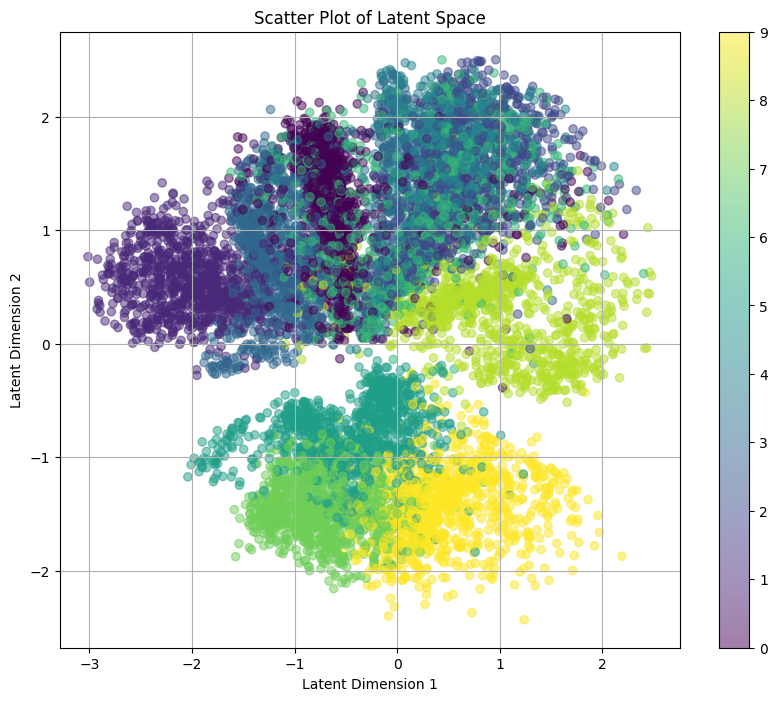

In [19]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_mean_vectors[:, 0], latent_mean_vectors[:, 1], c=labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
plt.title('Scatter Plot of Latent Space')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True)
plt.show()

In [24]:
def plot_latent_images(vae, n, digit_size=28):
    """Plots n x n digit images decoded from the latent space."""
        
    norm = Normal(0, 1)
    # Create grid values similar to percentiles
    grid_x = norm.icdf(torch.linspace(0.05, 0.95, n))
    grid_y = norm.icdf(torch.linspace(0.05, 0.95, n))
    image_width = digit_size * n
    image_height = image_width
    image = np.zeros((image_height, image_width))
    
    vae.eval()
    with torch.no_grad(): 
        for i, yi in enumerate(grid_x):
            for j, xi in enumerate(grid_y):
                z = torch.tensor([[xi.item(), yi.item()]], device=device).float()
                x_decoded = vae.decoder(z) 
                digit = x_decoded.view(digit_size, digit_size).cpu().numpy()  # Reshape and convert to numpy
                image[i * digit_size: (i + 1) * digit_size,
                      j * digit_size: (j + 1) * digit_size] = digit
    
    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap='Greys_r')
    plt.axis('off')
    plt.show()

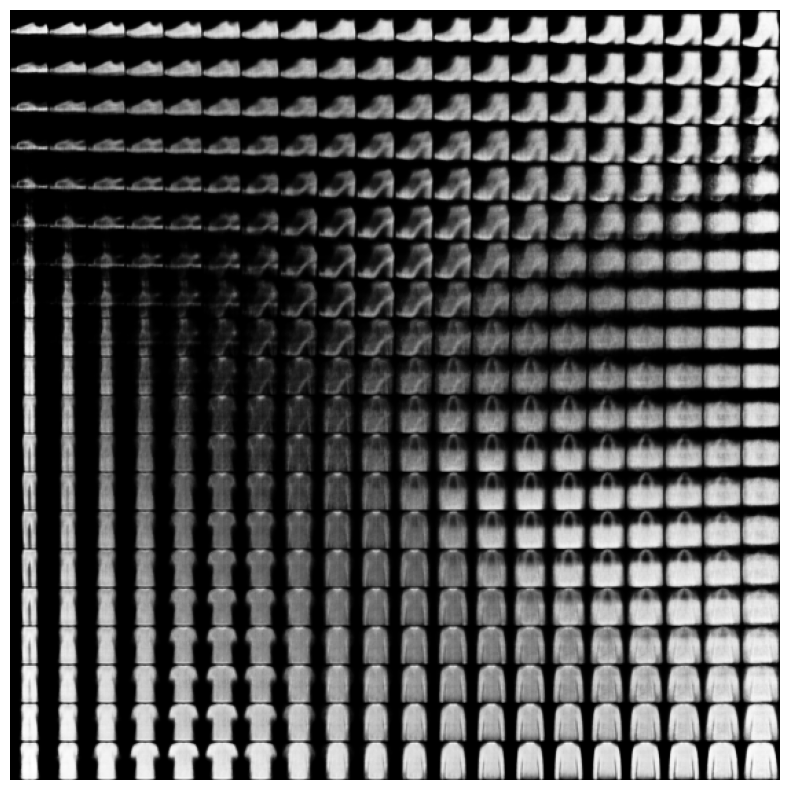

In [25]:
plot_latent_images(vae, 20)